155.9


  0%|                                                                                         | 0/2490 [00:00<?, ?it/s]C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
  0%|                                                                               | 1/2490 [00:01<1:13:30,  1.77s/it]C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in 

0.738


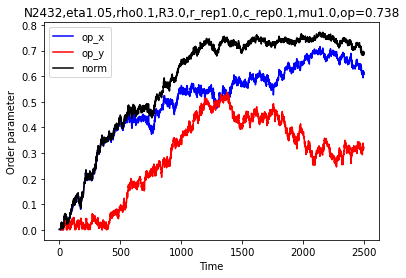

  0%|                                                                                         | 0/2486 [00:00<?, ?it/s]C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
100%|██████████████████████████████████████████████████████████████████████████████| 2486/2486 [07:34<00:00,  5.47it/s]


0.483


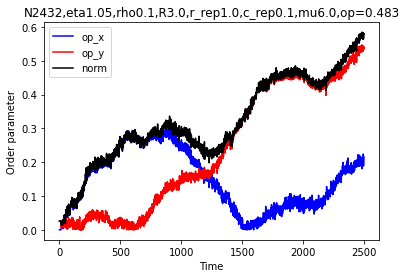

  0%|                                                                                         | 0/2482 [00:00<?, ?it/s]C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
100%|██████████████████████████████████████████████████████████████████████████████| 2482/2482 [07:33<00:00,  5.47it/s]


0.792


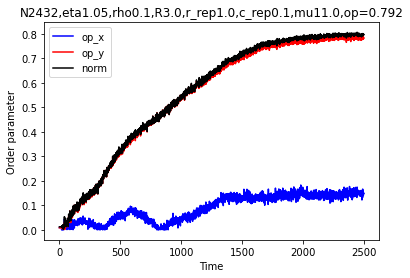

  0%|                                                                                         | 0/2478 [00:00<?, ?it/s]C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
100%|██████████████████████████████████████████████████████████████████████████████| 2478/2478 [07:31<00:00,  5.49it/s]


0.659


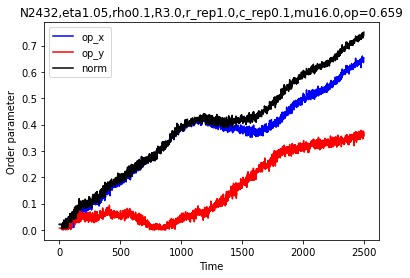

  0%|                                                                                         | 0/2474 [00:00<?, ?it/s]C:\Users\pc\anaconda3\lib\site-packages\numba\cuda\cudadrv\devicearray.py:885: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
  5%|████▎                                                                          | 135/2474 [00:25<06:55,  5.63it/s]

In [ ]:
from __future__ import division
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
import os
import shutil
import cv2
import glob
import itertools
import math 
from math import sqrt
from random import randint
from tqdm import tqdm
from numba import njit, jit, cuda, float32
import Flock2D_Module_Noise


N=2432
rho=0.1
L0=np.round((N/rho)**(1/2), 1)
#rho=np.round(N/(L0**3),2)
v0=0.05
v_max=3.0*v0
r=3.0
r_rep=1.0
c_rep=0.1
eta=2*np.pi/6
mu=1.0
s=mu/5
T0=int(4*s+10) 
dt=1.0
dit=6
BpG=38
tpB=64
T=2500
random_number=randint(0,10000)
center = np.array([0,0])
blocks_per_grid = (BpG,1)
threads_per_block = (tpB,2)
No=1

print(L0)


dir = os.path.join("Flock2D_PBC_Delay\August18\Frames/")
if os.path.exists(dir):
    original = r"Flock2D_PBC_Delay\August18\Frames/"
    target = r"Flock2D_PBC_Delay\August18\Repository/"
    shutil.move(original, target)
    
dir = os.path.join("Flock2D_PBC_Delay\August18\Repository\Frames/")  
if os.path.exists(dir):
    source = "Flock2D_PBC_Delay\August18\Repository\Frames/"
    dest = "Flock2D_PBC_Delay\August18\Repository\Frames_N"+str(N)+"_"+str(random_number)+"/"
    os.rename(source, dest)

dir = os.path.join("Flock2D_PBC_Delay\August18\Frames/")
if not os.path.exists(dir):
    os.mkdir(dir)
    


def ploting(op, op_stationary):

    x = np.arange(0,T-1)
    y1 = op[:,0]
    y2 = op[:,1]

    plt.title('N'+str(N)+',eta'+str(np.round(eta,2))+',rho'+str(rho)+",R"+ str(r)+",r_rep"+str(r_rep)+ ",c_rep"+str(c_rep)+',mu'+str(mu)+ ",op=" +str(op_stationary))
    plt.ylabel("Order parameter") 
    plt.xlabel("Time") 
    plt.plot(x, y1[:-1], 'b', label='op_x')
    plt.plot(x, y2[:-1], 'r', label='op_y')

    plt.plot(x, np.sqrt(y1**2 + y2**2)[:-1], 'black', label='norm')

    plt.savefig('Flock2D_PBC_Delay\August18\Order_parameter/N'+str(N)+'_eta'+str(np.round(eta,2))+'_rho'+str(rho)+'_R'+str(r)+'_rrep'+str(r_rep)+'_crep'+str(c_rep)+'_mu'+str(mu)+'_v'+str(v0)+'_T'+str(T)+'_'+str(No)+'.png')

    plt.legend()
    plt.show()
    
#making video

def video_making():
    image_folder = 'Flock2D_PBC_Delay\August18\Frames'
    video_name = 'Flock2D_PBC_Delay\August18\Videos/N'+str(N)+'_eta'+str(np.round(eta,2))+'_rho'+str(rho)+'_R'+str(r)+'_rrep'+str(r_rep)+'_crep'+str(c_rep)+'_mu'+str(mu)+'_v'+str(v0)+'_T'+str(T)+'_'+str(No)+'.mp4'
    images=['frame_VEM'+str(k)+'.png' for k in range(1,(T//dit)+1)]

    frame=cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = frame.shape
    video = cv2.VideoWriter(video_name, 0, 15, (width,height))

    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))

    cv2.destroyAllWindows()
    video.release()



while mu <= 40:

    op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
    ploting(op, op_stationary)
    video_making()
#     No+=1
#     eta+= np.pi/15
    mu+=5                                          
    s=mu/5
    T0=int(4*s+10) 
    
c_rep=0.3
while mu <= 40:

    op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
    ploting(op, op_stationary)
    video_making()
#     No+=1
#     eta+= np.pi/15
    mu+=3                                          
    s=mu/5
    T0=int(4*s+10)

c_rep=0.5
while mu <= 40:

    op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
    ploting(op, op_stationary)
    video_making()
#     No+=1
#     eta+= np.pi/15
    mu+=3                                          
    s=mu/5
    T0=int(4*s+10)
    

c_rep=0.7
while mu <= 40:

    op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
    ploting(op, op_stationary)
    video_making()
#     No+=1
#     eta+= np.pi/15
    mu+=3                                          
    s=mu/5
    T0=int(4*s+10)
    
c_rep=0.9
while mu <= 40:

    op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
    ploting(op, op_stationary)
    video_making()
#     No+=1
#     eta+= np.pi/15
    mu+=3                                          
    s=mu/5
    T0=int(4*s+10)
       
c_rep=1.2
while mu <= 40:

    op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
    ploting(op, op_stationary)
    video_making()
#     No+=1
#     eta+= np.pi/15
    mu+=3                                          
    s=mu/5
    T0=int(4*s+10)
    
# c_rep=0.7
# while mu <= 40:

#     op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
#     ploting(op, op_stationary)
#     video_making()
# #     No+=1
# #     eta+= np.pi/15
#     mu+=3                                          
#     s=mu/5
#     T0=int(4*s+10)

# c_rep=0.8
# while mu <= 40:

#     op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
#     ploting(op, op_stationary)
#     video_making()
# #     No+=1
# #     eta+= np.pi/15
#     mu+=3                                          
#     s=mu/5
#     T0=int(4*s+10) 
    
# c_rep=0.9
# while mu <= 40:

#     op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
#     ploting(op, op_stationary)
#     video_making()
# #     No+=1
# #     eta+= np.pi/15
#     mu+=3                                          
#     s=mu/5
#     T0=int(4*s+10)
    
# c_rep=1.0
# while mu <= 40:

#     op , op_stationary= Flock2D_Module_Noise.calc_x_v(eta, rho, T, N, L0, mu, s, T0, r, r_rep, c_rep, v0, v_max,blocks_per_grid, threads_per_block,dt, dit)
#     ploting(op, op_stationary)
#     video_making()
# #     No+=1
# #     eta+= np.pi/15
#     mu+=3                                          
#     s=mu/5
#     T0=int(4*s+10)